In [1]:
import numpy as np
import matplotlib.pyplot as plt

from hp_core import (
    lyapunov_spectrum_blocks,
    spectrum_statistics,
    z_maxima
)

In [2]:
# Fixed HP parameters

a1 = 5.0
a2 = 0.1
b1 = 3.0
b2 = 2.0
d2 = 0.01

initial_state = np.array([
    1.0,
    1.0,
    1.0
])

dt = 0.01


# Integration times

transient_time = 20000.0
alignment_time = 5000.0
average_time = 20000.0

renormalization_time = 1.0
block_time = 500.0

record_time = 20000.0
max_peaks = 500

In [3]:
# Global d1 scan

d1_scan = np.arange(
    0.3500,
    0.5000 + 0.00025,
    0.0005
)

d1_scan = np.round(
    d1_scan,
    4
)

print("Number of d1 values:")
print(len(d1_scan))

Number of d1 values:
301


In [4]:
scan_results = []
scan_blocks = []
scan_maxima = []

In [5]:
for i, d1_value in enumerate(d1_scan):

    parameters = np.array([
        a1,
        a2,
        b1,
        b2,
        d1_value,
        d2
    ])


    # Lyapunov spectrum

    block_exponents, final_state, _ = lyapunov_spectrum_blocks(
        parameters,
        initial_state,
        dt,
        transient_time,
        alignment_time,
        average_time,
        renormalization_time,
        block_time
    )

    (
        spectrum,
        errors,
        _,
        _,
        _,
        stationary
    ) = spectrum_statistics(block_exponents)


    # Save the Lyapunov blocks

    for block, block_values in enumerate(block_exponents, start=1):

        scan_blocks.append([
            d1_value,
            block,
            block_values[0],
            block_values[1],
            block_values[2]
        ])


    # Successive maxima of z

    maxima, _ = z_maxima(
        parameters,
        initial_state,
        dt,
        transient_time,
        record_time,
        max_peaks
    )

    distinct_maxima = len(
        np.unique(
            np.round(maxima, 3)
        )
    )


    # Save the summary for this d1

    scan_results.append([
        d1_value,
        spectrum[0],
        errors[0],
        spectrum[1],
        errors[1],
        spectrum[2],
        errors[2],
        distinct_maxima,
        stationary[0],
        stationary[1],
        stationary[2],
        final_state[0],
        final_state[1],
        final_state[2]
    ])


    # Save the maxima for the bifurcation diagram

    for z_peak in maxima:

        scan_maxima.append([
            d1_value,
            z_peak
        ])


    print(
        f"[{i + 1:03d}/{len(d1_scan)}] "
        f"d1 = {d1_value:.4f}   "
        f"lambda1 = {spectrum[0]:.6f}   "
        f"lambda2 = {spectrum[1]:.6f}   "
        f"distinct maxima = {distinct_maxima}",
        flush=True
    )

[001/301] d1 = 0.3500   lambda1 = 0.013741   lambda2 = -0.000221   distinct maxima = 442
[002/301] d1 = 0.3505   lambda1 = 0.012566   lambda2 = -0.000004   distinct maxima = 441
[003/301] d1 = 0.3510   lambda1 = 0.013108   lambda2 = -0.000016   distinct maxima = 450
[004/301] d1 = 0.3515   lambda1 = 0.013518   lambda2 = -0.000009   distinct maxima = 429
[005/301] d1 = 0.3520   lambda1 = 0.013516   lambda2 = 0.000136   distinct maxima = 450
[006/301] d1 = 0.3525   lambda1 = 0.012654   lambda2 = -0.000014   distinct maxima = 401
[007/301] d1 = 0.3530   lambda1 = 0.012732   lambda2 = 0.000107   distinct maxima = 437
[008/301] d1 = 0.3535   lambda1 = 0.012330   lambda2 = -0.000120   distinct maxima = 452
[009/301] d1 = 0.3540   lambda1 = 0.011238   lambda2 = 0.000082   distinct maxima = 389
[010/301] d1 = 0.3545   lambda1 = 0.011524   lambda2 = -0.000012   distinct maxima = 428
[011/301] d1 = 0.3550   lambda1 = 0.011844   lambda2 = -0.000034   distinct maxima = 421
[012/301] d1 = 0.3555   

In [6]:
scan_results = np.array(
    scan_results,
    dtype=float
)

scan_blocks = np.array(
    scan_blocks,
    dtype=float
)

scan_maxima = np.array(
    scan_maxima,
    dtype=float
)

print("Results:", scan_results.shape)
print("Blocks:", scan_blocks.shape)
print("Maxima:", scan_maxima.shape)

Results: (301, 14)
Blocks: (12040, 5)
Maxima: (101537, 2)


In [7]:
scan_header = """Global Hastings-Powell scan in d1
d1 range = 0.3500 to 0.5000
d1 step = 0.0005

a1 = 5.0
a2 = 0.1
b1 = 3.0
b2 = 2.0
d2 = 0.01

dt = 0.01
transient_time = 20000
alignment_time = 5000
average_time = 20000
renormalization_time = 1
block_time = 500
initial_state = [1.0, 1.0, 1.0]

errors = half-width of approximate 95% Student interval

columns:
d1,lambda1,error1,lambda2,error2,lambda3,error3,distinct_maxima,
stationary1,stationary2,stationary3,final_x,final_y,final_z
"""

np.savetxt(
    "data/hp_global_d1_scan.csv",
    scan_results,
    delimiter=",",
    header=scan_header,
    comments="# "
)

print("Saved: data/hp_global_d1_scan.csv")

Saved: data/hp_global_d1_scan.csv


In [8]:
blocks_header = """Lyapunov blocks for the global d1 scan
d1 range = 0.3500 to 0.5000
d1 step = 0.0005

a1 = 5.0
a2 = 0.1
b1 = 3.0
b2 = 2.0
d2 = 0.01

dt = 0.01
transient_time = 20000
alignment_time = 5000
average_time = 20000
renormalization_time = 1
block_time = 500
initial_state = [1.0, 1.0, 1.0]

columns:
d1,block,lambda1_block,lambda2_block,lambda3_block
"""

np.savetxt(
    "data/hp_global_d1_scan_blocks.csv",
    scan_blocks,
    delimiter=",",
    header=blocks_header,
    comments="# "
)

print("Saved: data/hp_global_d1_scan_blocks.csv")

Saved: data/hp_global_d1_scan_blocks.csv


In [9]:
maxima_header = """Successive maxima of z for the global d1 scan
d1 range = 0.3500 to 0.5000
d1 step = 0.0005

dt = 0.01
transient_time = 20000
record_time = 20000
initial_state = [1.0, 1.0, 1.0]

columns: d1,z_max
"""

np.savetxt(
    "data/hp_global_d1_scan_maxima.csv",
    scan_maxima,
    delimiter=",",
    header=maxima_header,
    comments="# "
)

print("Saved: data/hp_global_d1_scan_maxima.csv")

Saved: data/hp_global_d1_scan_maxima.csv


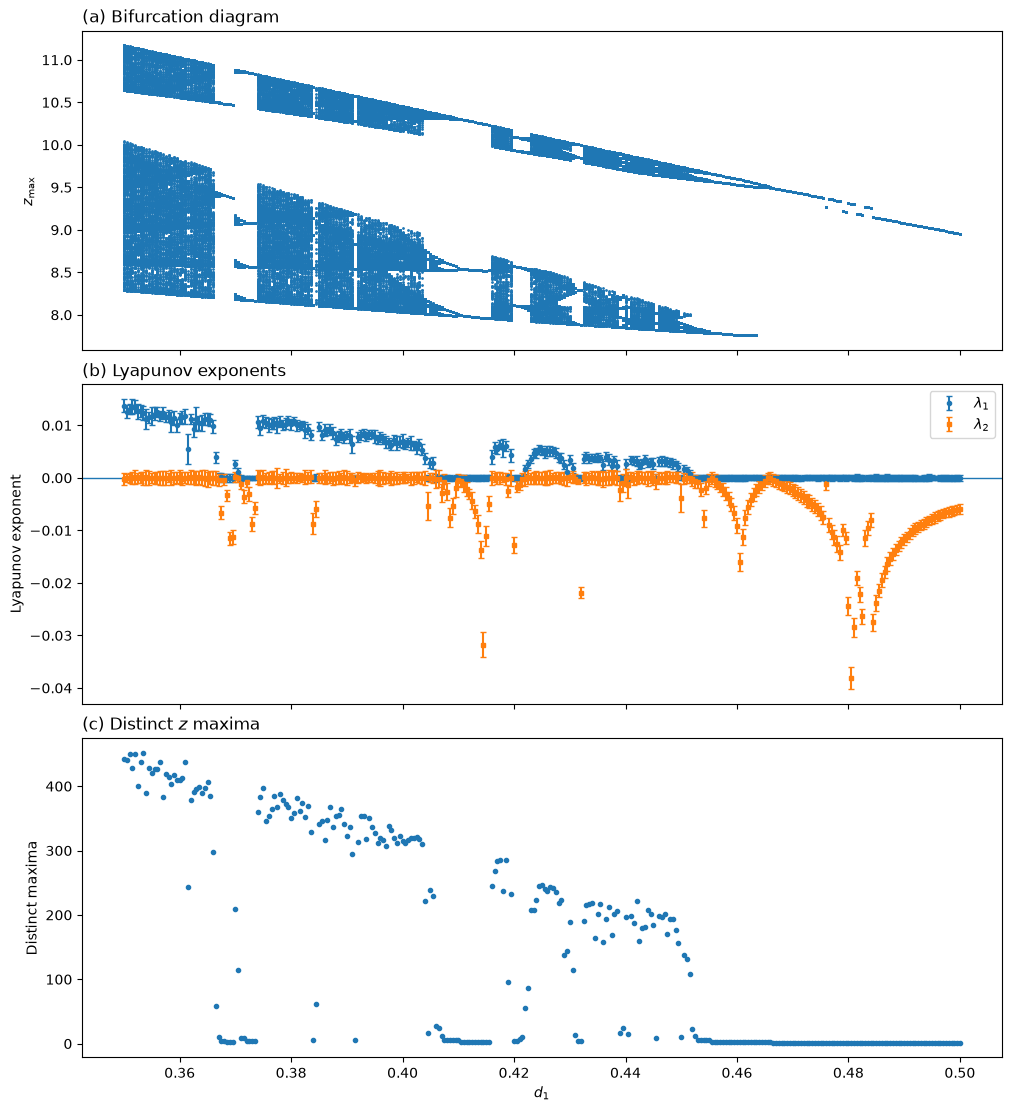

In [10]:
d1_values = scan_results[:, 0]

lambda1 = scan_results[:, 1]
error1 = scan_results[:, 2]

lambda2 = scan_results[:, 3]
error2 = scan_results[:, 4]

distinct_maxima = scan_results[:, 7]


fig, axes = plt.subplots(
    3,
    1,
    figsize=(10, 11),
    sharex=True,
    constrained_layout=True
)


# (a) Bifurcation diagram

axes[0].scatter(
    scan_maxima[:, 0],
    scan_maxima[:, 1],
    s=1
)

axes[0].set_ylabel(
    r"$z_{\max}$"
)

axes[0].set_title(
    "(a) Bifurcation diagram",
    loc="left"
)


# (b) First and second Lyapunov exponents

axes[1].errorbar(
    d1_values,
    lambda1,
    yerr=error1,
    fmt="o",
    markersize=3,
    capsize=2,
    linestyle="none",
    label=r"$\lambda_1$"
)

axes[1].errorbar(
    d1_values,
    lambda2,
    yerr=error2,
    fmt="s",
    markersize=3,
    capsize=2,
    linestyle="none",
    label=r"$\lambda_2$"
)

axes[1].axhline(
    0.0,
    linewidth=1
)

axes[1].set_ylabel(
    "Lyapunov exponent"
)

axes[1].set_title(
    "(b) Lyapunov exponents",
    loc="left"
)

axes[1].legend()


# (c) Number of distinct maxima

axes[2].plot(
    d1_values,
    distinct_maxima,
    "o",
    markersize=3
)

axes[2].set_xlabel(
    r"$d_1$"
)

axes[2].set_ylabel(
    "Distinct maxima"
)

axes[2].set_title(
    r"(c) Distinct $z$ maxima",
    loc="left"
)


fig.savefig(
    "figures/hp_global_d1_scan.png",
    dpi=300,
    bbox_inches="tight"
)

fig.savefig(
    "figures/hp_global_d1_scan.pdf",
    bbox_inches="tight"
)

plt.show()

In [11]:
# Upward continuation

continuation_up = []
continuation_up_maxima = []

state_up = initial_state.copy()


for i, d1_value in enumerate(d1_scan):

    parameters = np.array([
        a1,
        a2,
        b1,
        b2,
        d1_value,
        d2
    ])


    maxima, state_up = z_maxima(
        parameters,
        state_up,
        dt,
        transient_time,
        record_time,
        max_peaks
    )


    distinct_maxima = len(
        np.unique(
            np.round(maxima, 3)
        )
    )


    continuation_up.append([
        d1_value,
        distinct_maxima,
        state_up[0],
        state_up[1],
        state_up[2]
    ])


    for z_peak in maxima:

        continuation_up_maxima.append([
            d1_value,
            z_peak
        ])


    print(
        f"[{i + 1:03d}/{len(d1_scan)}] "
        f"d1 = {d1_value:.4f}   "
        f"distinct maxima = {distinct_maxima}",
        flush=True
    )

[001/301] d1 = 0.3500   distinct maxima = 442
[002/301] d1 = 0.3505   distinct maxima = 431
[003/301] d1 = 0.3510   distinct maxima = 416
[004/301] d1 = 0.3515   distinct maxima = 429
[005/301] d1 = 0.3520   distinct maxima = 421
[006/301] d1 = 0.3525   distinct maxima = 421
[007/301] d1 = 0.3530   distinct maxima = 423
[008/301] d1 = 0.3535   distinct maxima = 443
[009/301] d1 = 0.3540   distinct maxima = 392
[010/301] d1 = 0.3545   distinct maxima = 417
[011/301] d1 = 0.3550   distinct maxima = 438
[012/301] d1 = 0.3555   distinct maxima = 390
[013/301] d1 = 0.3560   distinct maxima = 393
[014/301] d1 = 0.3565   distinct maxima = 417
[015/301] d1 = 0.3570   distinct maxima = 420
[016/301] d1 = 0.3575   distinct maxima = 416
[017/301] d1 = 0.3580   distinct maxima = 414
[018/301] d1 = 0.3585   distinct maxima = 415
[019/301] d1 = 0.3590   distinct maxima = 443
[020/301] d1 = 0.3595   distinct maxima = 434
[021/301] d1 = 0.3600   distinct maxima = 447
[022/301] d1 = 0.3605   distinct m

In [12]:
# Downward continuation

continuation_down = []
continuation_down_maxima = []

state_down = state_up.copy()


for i, d1_value in enumerate(d1_scan[::-1]):

    parameters = np.array([
        a1,
        a2,
        b1,
        b2,
        d1_value,
        d2
    ])


    maxima, state_down = z_maxima(
        parameters,
        state_down,
        dt,
        transient_time,
        record_time,
        max_peaks
    )


    distinct_maxima = len(
        np.unique(
            np.round(maxima, 3)
        )
    )


    continuation_down.append([
        d1_value,
        distinct_maxima,
        state_down[0],
        state_down[1],
        state_down[2]
    ])


    for z_peak in maxima:

        continuation_down_maxima.append([
            d1_value,
            z_peak
        ])


    print(
        f"[{i + 1:03d}/{len(d1_scan)}] "
        f"d1 = {d1_value:.4f}   "
        f"distinct maxima = {distinct_maxima}",
        flush=True
    )

[001/301] d1 = 0.5000   distinct maxima = 1
[002/301] d1 = 0.4995   distinct maxima = 1
[003/301] d1 = 0.4990   distinct maxima = 1
[004/301] d1 = 0.4985   distinct maxima = 1
[005/301] d1 = 0.4980   distinct maxima = 1
[006/301] d1 = 0.4975   distinct maxima = 1
[007/301] d1 = 0.4970   distinct maxima = 1
[008/301] d1 = 0.4965   distinct maxima = 1
[009/301] d1 = 0.4960   distinct maxima = 1
[010/301] d1 = 0.4955   distinct maxima = 1
[011/301] d1 = 0.4950   distinct maxima = 1
[012/301] d1 = 0.4945   distinct maxima = 1
[013/301] d1 = 0.4940   distinct maxima = 1
[014/301] d1 = 0.4935   distinct maxima = 1
[015/301] d1 = 0.4930   distinct maxima = 1
[016/301] d1 = 0.4925   distinct maxima = 1
[017/301] d1 = 0.4920   distinct maxima = 1
[018/301] d1 = 0.4915   distinct maxima = 1
[019/301] d1 = 0.4910   distinct maxima = 1
[020/301] d1 = 0.4905   distinct maxima = 1
[021/301] d1 = 0.4900   distinct maxima = 1
[022/301] d1 = 0.4895   distinct maxima = 1
[023/301] d1 = 0.4890   distinct

In [13]:
continuation_up = np.array(
    continuation_up,
    dtype=float
)

continuation_up_maxima = np.array(
    continuation_up_maxima,
    dtype=float
)

continuation_down = np.array(
    continuation_down,
    dtype=float
)

continuation_down_maxima = np.array(
    continuation_down_maxima,
    dtype=float
)


# Put the downward continuation back in increasing d1 order

order_down = np.argsort(
    continuation_down[:, 0]
)

continuation_down = continuation_down[
    order_down
]


order_down_maxima = np.argsort(
    continuation_down_maxima[:, 0]
)

continuation_down_maxima = continuation_down_maxima[
    order_down_maxima
]


print("Up:", continuation_up.shape)
print("Down:", continuation_down.shape)

print("Up maxima:", continuation_up_maxima.shape)
print("Down maxima:", continuation_down_maxima.shape)

Up: (301, 5)
Down: (301, 5)
Up maxima: (101374, 2)
Down maxima: (101833, 2)


In [14]:
continuation_up_header = """Upward continuation of the Hastings-Powell d1 scan
computed from d1 = 0.3500 to 0.5000
d1 step = 0.0005

dt = 0.01
transient_time = 20000
record_time = 20000
initial_state at d1 = 0.3500 = [1.0, 1.0, 1.0]

Each d1 starts from the final state of the previous d1.

columns:
d1,distinct_maxima,final_x,final_y,final_z
"""

np.savetxt(
    "data/hp_global_d1_continuation_up.csv",
    continuation_up,
    delimiter=",",
    header=continuation_up_header,
    comments="# "
)


continuation_up_maxima_header = """Successive maxima of z for the upward d1 continuation
computed from d1 = 0.3500 to 0.5000
d1 step = 0.0005

dt = 0.01
transient_time = 20000
record_time = 20000

columns: d1,z_max
"""

np.savetxt(
    "data/hp_global_d1_continuation_up_maxima.csv",
    continuation_up_maxima,
    delimiter=",",
    header=continuation_up_maxima_header,
    comments="# "
)


continuation_down_header = """Downward continuation of the Hastings-Powell d1 scan
computed from d1 = 0.5000 to 0.3500
d1 step = 0.0005

dt = 0.01
transient_time = 20000
record_time = 20000

Each d1 starts from the final state of the previous d1.
Rows are stored in increasing d1 order for comparison.

columns:
d1,distinct_maxima,final_x,final_y,final_z
"""

np.savetxt(
    "data/hp_global_d1_continuation_down.csv",
    continuation_down,
    delimiter=",",
    header=continuation_down_header,
    comments="# "
)


continuation_down_maxima_header = """Successive maxima of z for the downward d1 continuation
computed from d1 = 0.5000 to 0.3500
d1 step = 0.0005

dt = 0.01
transient_time = 20000
record_time = 20000

Rows are stored in increasing d1 order for comparison.

columns: d1,z_max
"""

np.savetxt(
    "data/hp_global_d1_continuation_down_maxima.csv",
    continuation_down_maxima,
    delimiter=",",
    header=continuation_down_maxima_header,
    comments="# "
)


print("Saved upward and downward continuation data.")

Saved upward and downward continuation data.


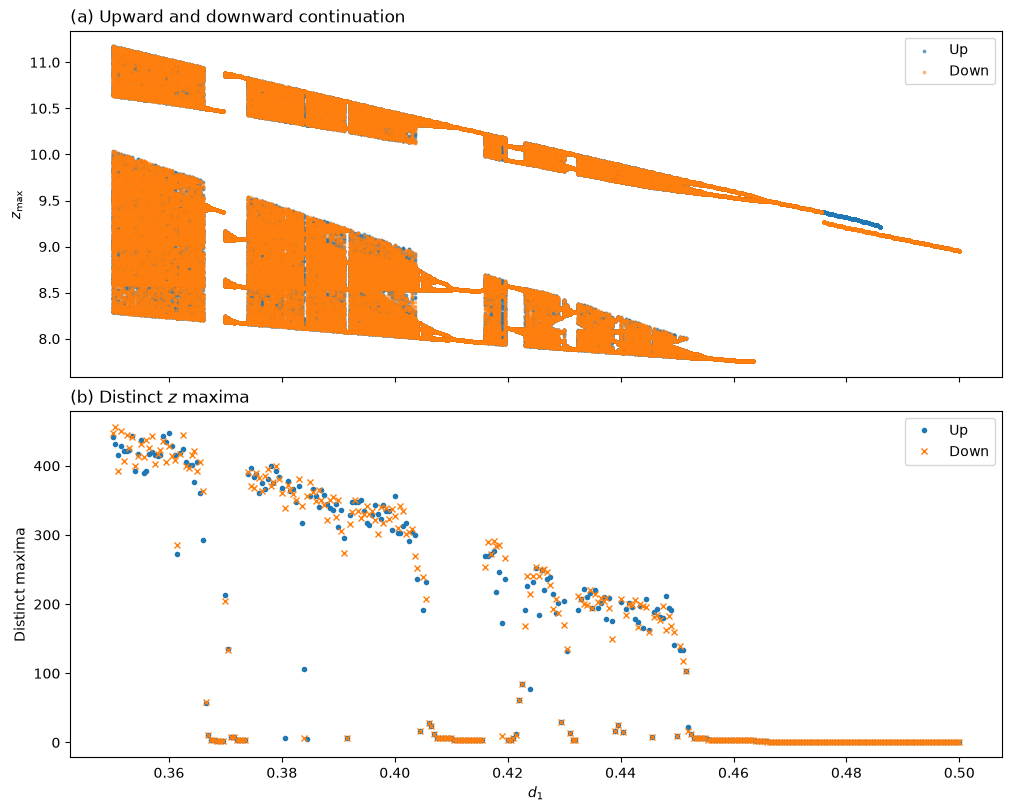

In [15]:
# Compare upward and downward continuations

d1_up = continuation_up[:, 0]
distinct_up = continuation_up[:, 1]

d1_down = continuation_down[:, 0]
distinct_down = continuation_down[:, 1]


fig, axes = plt.subplots(
    2,
    1,
    figsize=(10, 8),
    sharex=True,
    constrained_layout=True
)


# (a) Maxima of z

axes[0].scatter(
    continuation_up_maxima[:, 0],
    continuation_up_maxima[:, 1],
    s=3,
    alpha=0.6,
    label="Up"
)

axes[0].scatter(
    continuation_down_maxima[:, 0],
    continuation_down_maxima[:, 1],
    s=3,
    alpha=0.6,
    marker="x",
    label="Down"
)

axes[0].set_ylabel(
    r"$z_{\max}$"
)

axes[0].set_title(
    "(a) Upward and downward continuation",
    loc="left"
)

axes[0].legend()


# (b) Number of distinct maxima

axes[1].plot(
    d1_up,
    distinct_up,
    "o",
    markersize=3,
    label="Up"
)

axes[1].plot(
    d1_down,
    distinct_down,
    "x",
    markersize=4,
    label="Down"
)

axes[1].set_xlabel(
    r"$d_1$"
)

axes[1].set_ylabel(
    "Distinct maxima"
)

axes[1].set_title(
    r"(b) Distinct $z$ maxima",
    loc="left"
)

axes[1].legend()


fig.savefig(
    "figures/hp_global_d1_continuation.png",
    dpi=300,
    bbox_inches="tight"
)

fig.savefig(
    "figures/hp_global_d1_continuation.pdf",
    bbox_inches="tight"
)

plt.show()

In [16]:
# Compare the continuation branches

continuation_comparison = []


for d1_value in d1_scan:

    up_peaks = continuation_up_maxima[
        np.isclose(
            continuation_up_maxima[:, 0],
            d1_value
        ),
        1
    ]

    down_peaks = continuation_down_maxima[
        np.isclose(
            continuation_down_maxima[:, 0],
            d1_value
        ),
        1
    ]


    up_index = np.where(
        np.isclose(
            continuation_up[:, 0],
            d1_value
        )
    )[0][0]

    down_index = np.where(
        np.isclose(
            continuation_down[:, 0],
            d1_value
        )
    )[0][0]


    mean_up = np.mean(up_peaks)
    mean_down = np.mean(down_peaks)

    continuation_comparison.append([
        d1_value,
        mean_up,
        mean_down,
        abs(mean_up - mean_down),
        continuation_up[up_index, 1],
        continuation_down[down_index, 1]
    ])


continuation_comparison = np.array(
    continuation_comparison,
    dtype=float
)


# Show the largest differences in periodic regions

periodic = (
    (continuation_comparison[:, 4] <= 10)
    &
    (continuation_comparison[:, 5] <= 10)
)

periodic_comparison = continuation_comparison[
    periodic
]

order = np.argsort(
    periodic_comparison[:, 3]
)[::-1]


print(
    "d1       mean_up    mean_down    difference    up_maxima    down_maxima"
)

for row in periodic_comparison[order][:20]:

    print(
        f"{row[0]:.4f}   "
        f"{row[1]:.6f}   "
        f"{row[2]:.6f}   "
        f"{row[3]:.6f}   "
        f"{int(row[4]):3d}          "
        f"{int(row[5]):3d}"
    )

d1       mean_up    mean_down    difference    up_maxima    down_maxima
0.4785   9.336578   9.227279   0.109299     1            1
0.4780   9.343387   9.234139   0.109248     1            1
0.4790   9.329722   9.220526   0.109196     1            1
0.4775   9.350152   9.241149   0.109002     1            1
0.4795   9.322813   9.213852   0.108960     1            1
0.4800   9.315845   9.207241   0.108604     1            1
0.4770   9.356877   9.248396   0.108481     1            1
0.4805   9.308812   9.200679   0.108133     1            1
0.4810   9.301705   9.194158   0.107546     1            1
0.4765   9.363564   9.256085   0.107479     1            1
0.4815   9.294512   9.187672   0.106840     1            1
0.4820   9.287220   9.181214   0.106006     1            1
0.4825   9.279811   9.174782   0.105029     1            1
0.4760   9.370218   9.265241   0.104977     1            1
0.4830   9.272258   9.168371   0.103888     1            1
0.4835   9.264527   9.161979   0.102548    

In [17]:
# Save and identify separated continuation branches

comparison_header = """Comparison of upward and downward d1 continuations
d1 range = 0.3500 to 0.5000
d1 step = 0.0005

The branch difference is the absolute difference between
the mean successive maxima of z in the two continuations.

columns:
d1,mean_zmax_up,mean_zmax_down,difference,distinct_up,distinct_down
"""

np.savetxt(
    "data/hp_global_d1_continuation_comparison.csv",
    continuation_comparison,
    delimiter=",",
    header=comparison_header,
    comments="# "
)


# Look for clearly separated periodic branches

branch_tolerance = 0.01

periodic_mask = (
    (continuation_comparison[:, 4] <= 10)
    &
    (continuation_comparison[:, 5] <= 10)
)

separated_mask = (
    periodic_mask
    &
    (continuation_comparison[:, 3] > branch_tolerance)
)

separated_d1 = continuation_comparison[
    separated_mask,
    0
]


# Group consecutive d1 values

intervals = []

if len(separated_d1) > 0:

    start = separated_d1[0]
    previous = separated_d1[0]

    for value in separated_d1[1:]:

        if np.isclose(
            value - previous,
            0.0005
        ):

            previous = value

        else:

            intervals.append([
                start,
                previous
            ])

            start = value
            previous = value

    intervals.append([
        start,
        previous
    ])


print(
    "Saved: data/hp_global_d1_continuation_comparison.csv"
)

print(
    "Branch separation tolerance:",
    branch_tolerance
)

print("Separated periodic intervals:")

for start, end in intervals:

    print(
        f"d1 = {start:.4f} to {end:.4f}"
    )

Saved: data/hp_global_d1_continuation_comparison.csv
Branch separation tolerance: 0.01
Separated periodic intervals:
d1 = 0.4760 to 0.4860
